In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)


In [2]:
df = pd.read_excel('/kaggle/input/datasets/sanjeethpekumar/online-retail-xlsx/Online Retail.xlsx')

In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
df.shape

(541909, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.describe(include = 'object')

,InvoiceNo,StockCode,Description,Country
count,541909,541909,540455,541909
unique,25900,4070,4223,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1114,2313,2369,495478


In [9]:
(df['Country'].value_counts(normalize = True)*100).round(2).head(10)

Country
United Kingdom    91.43
Germany            1.75
France             1.58
EIRE               1.51
Spain              0.47
Netherlands        0.44
Belgium            0.38
Switzerland        0.37
Portugal           0.28
Australia          0.23
Name: proportion, dtype: float64

In [10]:
# 91% customer are from United Kingdom

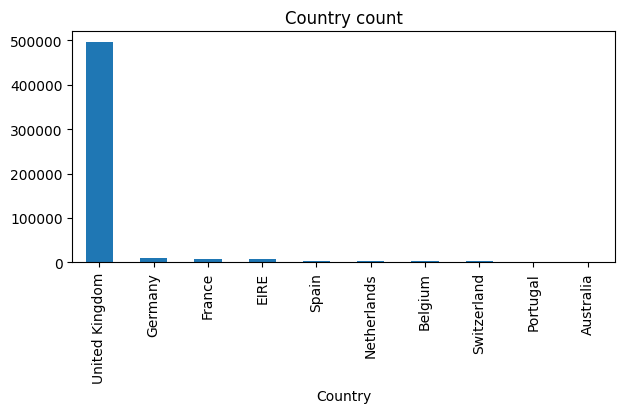

In [11]:
plt.figure(figsize = (7,3))
df['Country'].value_counts().head(10).plot(kind = 'bar')
plt.title('Country count')
plt.show()

In [12]:
# check for unique customer
df['CustomerID'].nunique()

4372

In [13]:
# data cleaning

In [14]:
df2 = df.copy()

In [15]:
df2.shape

(541909, 8)

In [16]:
df2.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [17]:
df2 = df2.dropna(subset = ['CustomerID'])

In [18]:
df2['CustomerID'].isnull().sum()

np.int64(0)

In [19]:
df2.shape

(406829, 8)

In [20]:
# convet customerID to integer
df2['CustomerID'] = df2['CustomerID'].astype(int)

In [21]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  int64         
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.9+ MB


In [22]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [23]:
df2.sample(50)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
530055,580776,22111,SCOTTIE DOG HOT WATER BOTTLE,7,2011-12-06 11:05:00,4.95,14562,United Kingdom
411081,572192,21328,BALLOONS WRITING SET,1,2011-10-21 11:30:00,1.65,18118,United Kingdom
335461,566288,23356,LOVE HOT WATER BOTTLE,3,2011-09-11 15:18:00,5.95,12883,United Kingdom
241537,558232,22980,PANTRY SCRUBBING BRUSH,4,2011-06-27 14:30:00,1.65,17841,United Kingdom
150549,549448,22682,FRENCH BLUE METAL DOOR SIGN 7,10,2011-04-08 14:07:00,1.25,13078,United Kingdom
134857,547871,22381,TOY TIDY PINK POLKADOT,1,2011-03-27 14:28:00,2.10,16931,United Kingdom
244744,558540,22988,SOLDIERS EGG CUP,24,2011-06-30 12:15:00,1.25,17706,United Kingdom
208193,555106,22712,CARD DOLLY GIRL,12,2011-05-31 14:14:00,0.42,12790,Netherlands
133398,547785,22846,BREAD BIN DINER STYLE RED,1,2011-03-25 11:41:00,16.95,13097,United Kingdom
225866,556734,23163,REGENCY SUGAR TONGS,8,2011-06-14 12:00:00,2.49,13476,United Kingdom


In [24]:
# Cancle order is started with C need to remove the cancel order it is in invoiceNo

In [25]:
df2 = df2[~df2['InvoiceNo'].astype(str).str.startswith('C')]

In [26]:
df2.shape

(397924, 8)

In [27]:
# Negative quantity usually show returns need to remove

In [28]:
df2 = df2[df2['Quantity'] > 0]

In [29]:
df2.shape

(397924, 8)

In [30]:
df2.select_dtypes(include = 'number').min().min()

0.0

In [31]:
df.select_dtypes(include = 'number').min().min()

-80995.0

In [32]:
df['Quantity'].min()

-80995

In [33]:
# Remove Zero Price product

In [34]:
df2['UnitPrice'].min()

0.0

In [35]:
df2 = df2[df2['UnitPrice'] > 0]

In [36]:
df2.shape

(397884, 8)

In [37]:
df2.duplicated().sum()

np.int64(5192)

In [38]:
df2.drop_duplicates(inplace = True)

In [39]:
df2.shape

(392692, 8)

In [40]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392692 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392692 non-null  object        
 1   StockCode    392692 non-null  object        
 2   Description  392692 non-null  object        
 3   Quantity     392692 non-null  int64         
 4   InvoiceDate  392692 non-null  datetime64[ns]
 5   UnitPrice    392692 non-null  float64       
 6   CustomerID   392692 non-null  int64         
 7   Country      392692 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.0+ MB


In [41]:
# Creating Total Price Feature

In [42]:
df2['totalPrice'] = df2['Quantity'] * df2['UnitPrice']

In [43]:
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,totalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [44]:
print('Total Rows:',df2.shape[0])
print('Total Columns:',df2.shape[1])
print('Unique Customer:',df2['CustomerID'].nunique())

Total Rows: 392692
Total Columns: 9
Unique Customer: 4338


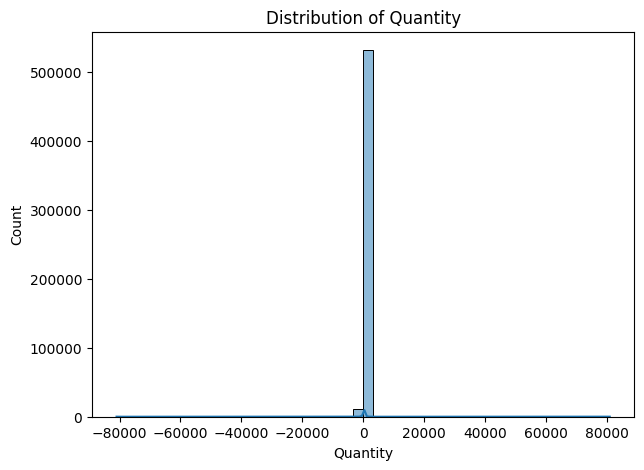

In [45]:
plt.figure(figsize = (7,5))
sns.histplot(df['Quantity'],kde = True,bins = 50)
plt.title('Distribution of Quantity')
plt.show()

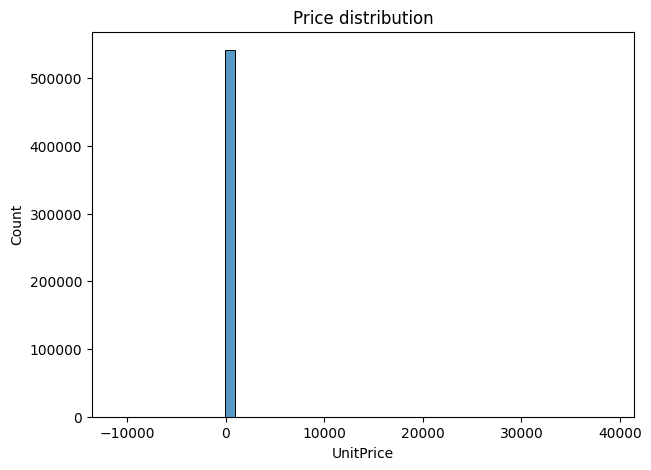

In [47]:
plt.figure(figsize = (7,5))
sns.histplot(df['UnitPrice'],bins = 50)
plt.title('Price distribution')
plt.show()

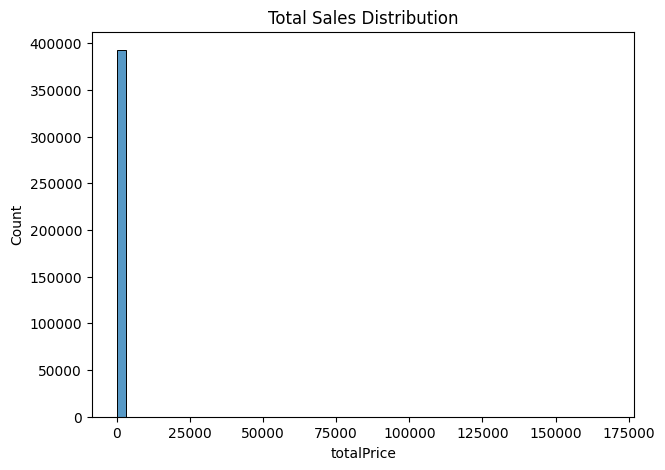

In [49]:
plt.figure(figsize = (7,5))
sns.histplot(df2['totalPrice'],bins = 50)
plt.title('Total Sales Distribution')
plt.show()

In [50]:
# RFM = Recency + Frequency + Monetary

In [52]:
reference_date = df['InvoiceDate'].max()
print(reference_date)

2011-12-09 12:50:00


In [54]:
rfm_recency = df2.groupby('CustomerID')['InvoiceDate'].max().reset_index()
rfm_recency['Recency'] = (reference_date - rfm_recency['InvoiceDate']).dt.days
rfm_recency.head()

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,325
1,12347,2011-12-07 15:52:00,1
2,12348,2011-09-25 13:13:00,74
3,12349,2011-11-21 09:51:00,18
4,12350,2011-02-02 16:01:00,309


In [55]:
# Frequency Feature

In [56]:
rfm_frequency = df2.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
rfm_frequency.columns = ['CustomerID','Frequency']
rfm_frequency.head()

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1


In [57]:
rfm_monetary = df2.groupby('CustomerID')['totalPrice'].sum().reset_index()
rfm_monetary.columns = ['CustomerID','monetary']
rfm_monetary.head()


,CustomerID,monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40


In [58]:
# Merge RFM Features

In [60]:
rfm = rfm_recency[['CustomerID','Recency']]
rfm = rfm.merge(rfm_frequency,on = 'CustomerID')
rfm = rfm.merge(rfm_monetary,on = 'CustomerID')

In [61]:
rfm.head()

,CustomerID,Recency,Frequency,monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [62]:
rfm.shape

(4338, 4)

In [63]:
rfm.describe()

,CustomerID,Recency,Frequency,monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,91.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,0.000000,1.000000,3.750000
25%,13813.250000,17.000000,1.000000,306.482500
50%,15299.500000,50.000000,2.000000,668.570000
75%,16778.750000,141.000000,5.000000,1660.597500
max,18287.000000,373.000000,209.000000,280206.020000


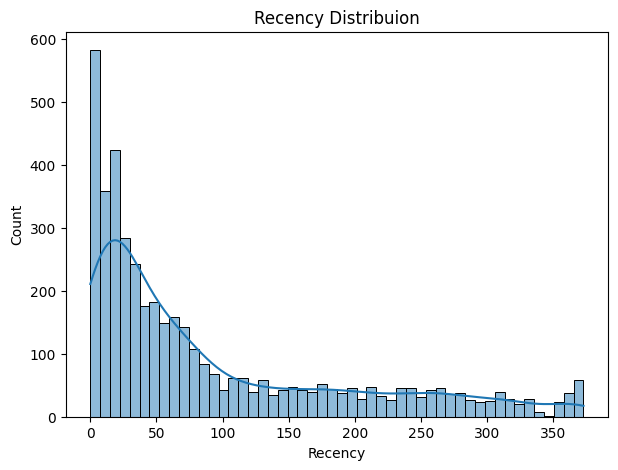

In [66]:
# Recency Distribution
plt.figure(figsize = (7,5))
sns.histplot(rfm['Recency'],bins = 50,kde = True)
plt.title('Recency Distribuion')
plt.show()

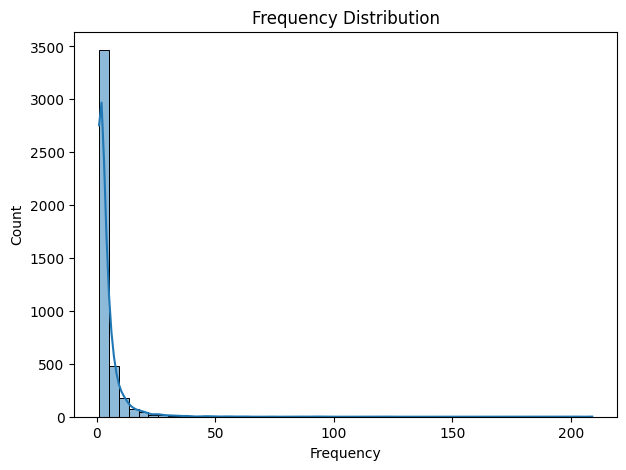

In [70]:
# Frequency Distribution
plt.figure(figsize = (7,5))
sns.histplot(rfm['Frequency'],bins = 50,kde = True)
plt.title('Frequency Distribution')
plt.show()

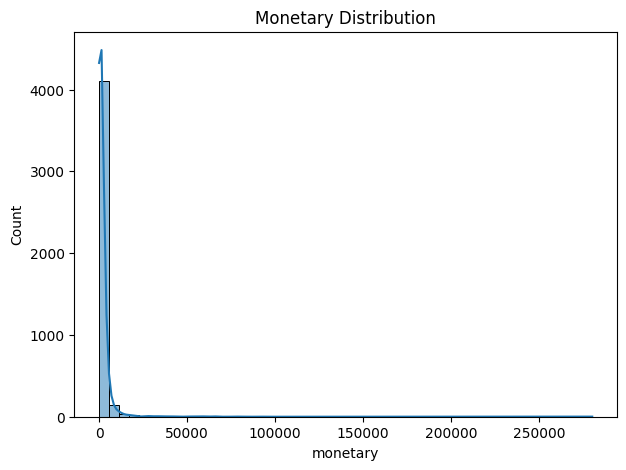

In [71]:
# Monetary Distribution
plt.figure(figsize = (7,5))
sns.histplot(rfm['monetary'],bins = 50,kde = True)
plt.title('Monetary Distribution')
plt.show()

In [72]:
# Now we will make the customer Segment from rfm

In [73]:
rfm_model = rfm.drop(['CustomerID'],axis = 1)

In [74]:
rfm_model.head()

,Recency,Frequency,monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


In [76]:
# for compressing the outlier we will do the Log Transformation

In [77]:
rfm_log = np.log1p(rfm_model)

In [78]:
rfm_log.head()

,Recency,Frequency,monetary
0,5.786897,0.693147,11.253955
1,0.693147,2.079442,8.368925
2,4.317488,1.609438,7.494564
3,2.944439,0.693147,7.472245
4,5.736572,0.693147,5.815324


In [79]:
rfm_log.describe()

,Recency,Frequency,monetary
count,4338.000000,4338.000000,4338.000000
mean,3.767534,1.345582,6.588562
std,1.432445,0.683104,1.258438
min,0.000000,0.693147,1.558145
25%,2.890372,0.693147,5.728418
50%,3.931826,1.098612,6.506636
75%,4.955827,1.791759,7.415535
max,5.924256,5.347108,12.543284


In [102]:
# KMeans is distance based algorithm so scaling is essential for it
#Feature	Meaning
#Recency	last purchase gap
#Frequency	number of purchases
#Monetary	total spending

In [81]:
scaler = StandardScaler()

In [82]:
rfm_scaled = scaler.fit_transform(rfm_log)

In [83]:
rfm_scaled

array([[ 1.40989446, -0.95521426,  3.7077163 ],
       [-2.14649825,  1.07442519,  1.41490344],
       [ 0.38397128,  0.38630445,  0.72002428],
       ...,
       [-1.17860486, -0.36158278, -1.11333158],
       [-1.66255156,  2.17800394,  0.82281217],
       [-0.00442205,  0.05960547,  0.73752572]])

In [84]:
# Elbow Method (Optimal Clusters)

In [88]:
inertia = []
k_range = range(1,11)
for k in k_range:
    kmeans = KMeans(n_clusters = k,random_state = 42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

In [89]:
inertia

[13013.999999999985,
 6502.1337863139415,
 4893.2945910489725,
 3987.643659771542,
 3371.8012841116183,
 2901.5887096414,
 2613.7552963457388,
 2405.1434769815073,
 2201.345214738757,
 2091.323659447394]

In [92]:
# Inertia = Within-cluster sum of squares (WCSS)

# Matlab: Har cluster ke andar points apne centroid se kitne door hain, un distances ka sum
# Chhota inertia = zada compact/consistent clusters
# "Elbow point": Jahaan inertia girna slow ho jaye

# Wahi optimal k hota hai
# k too small → Different customer behaviors mix ho jayenge

# k too large → Overfitting, har customer ka alag cluster

# Optimal k → Meaningful customer segments milein ge

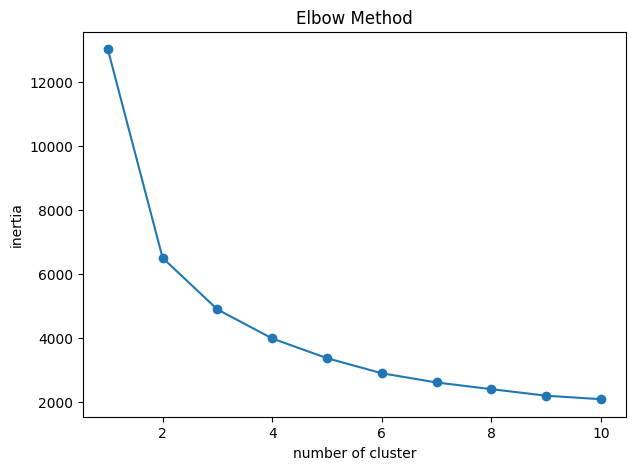

In [93]:
# Elbow plot
plt.figure(figsize = (7,5))
plt.plot(k_range,inertia,marker = 'o')
plt.xlabel('number of cluster')
plt.ylabel('inertia')
plt.title('Elbow Method')
plt.show()


In [94]:
# Silhouette Score
for k in range(2,7):
    kmeans = KMeans(n_clusters = k,random_state = 42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled,labels)
    print('K=',k,'Score = ',score)

K= 2 Score =  0.4343591972869044
K= 3 Score =  0.33897314797167083
K= 4 Score =  0.33561136654962703
K= 5 Score =  0.31494688003493476
K= 6 Score =  0.3100686015529931


In [95]:
# for k = 2 silhouette score is high so it will be the best cluster 
# hence on the basis of silhouette and elbow the best cluster is k = 2

In [97]:
# Train the Model
kmeans = KMeans(n_clusters = 2,random_state = 42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [98]:
rfm.groupby('Cluster').mean()

,CustomerID,Recency,Frequency,monetary
Cluster,,,,
0,15351.130078,132.702572,1.676854,498.221954
1,15218.180060,24.800000,8.479154,4562.223197


In [100]:
#     Cluster	Type
# 0	Low Value / At Risk
# 1	High Value / Loyal

In [101]:
# PCA Cluster Visualization

In [103]:
from sklearn.decomposition import PCA

In [104]:
pca = PCA(n_components = 2)

In [105]:
pca_feature = pca.fit_transform(rfm_scaled)

In [106]:
pca_feature

array([[ 0.89864608,  2.65628754],
       [ 2.60706887, -0.89274523],
       [ 0.47160406,  0.75758858],
       ...,
       [-0.28399593, -1.60693261],
       [ 2.68844403, -0.46836685],
       [ 0.47893466,  0.35119631]])

In [107]:
pca_df = pd.DataFrame(pca_feature,columns = ['PCA1','PCA2'])

In [108]:
pca_df['Cluster'] = rfm['Cluster']

In [110]:
pca_df.head()

,PCA1,PCA2,Cluster
0,0.898646,2.656288,1
1,2.607069,-0.892745,1
2,0.471604,0.757589,1
3,0.122517,-0.412234,0
4,-1.660910,0.636819,0


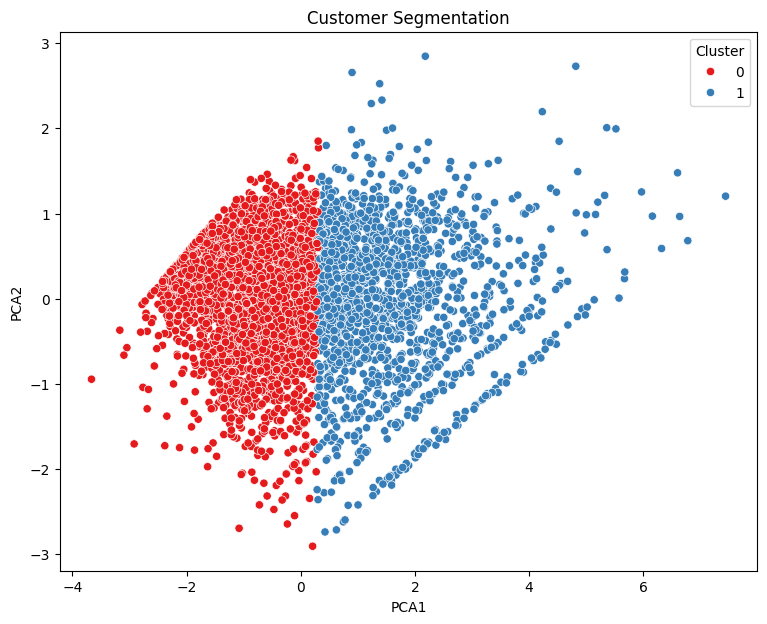

In [111]:
plt.figure(figsize = (9,7))
sns.scatterplot(x = 'PCA1',y = 'PCA2',data = pca_df,hue = 'Cluster',palette = 'Set1')
plt.title('Customer Segmentation')
plt.show()

In [112]:
# Explained Variance
pca.explained_variance_ratio_

array([0.75090484, 0.18786137])

In [113]:
#Component	Variance Explained
#PC1	0.7509 ≈ 75%
#PC2	0.1878 ≈ 18.7%
# there are 3 feature through pca we make 2 feature and it shows 94% information retained by these 2.

KMeans clustering identified two major customer segments.

Cluster 1 represents high-value loyal customers with high
frequency and high monetary value.

Cluster 0 represents low-value or at-risk customers with
low spending and infrequent purchases.

In [114]:
rfm.head()

,CustomerID,Recency,Frequency,monetary,Cluster
0,12346,325,1,77183.60,1
1,12347,1,7,4310.00,1
2,12348,74,4,1797.24,1
3,12349,18,1,1757.55,0
4,12350,309,1,334.40,0


In [115]:
cluster_profile = rfm.drop(['CustomerID'],axis = 1).groupby('Cluster').mean()

In [118]:
cluster_profile.round(2)

,Recency,Frequency,monetary
Cluster,,,
0,132.7,1.68,498.22
1,24.8,8.48,4562.22


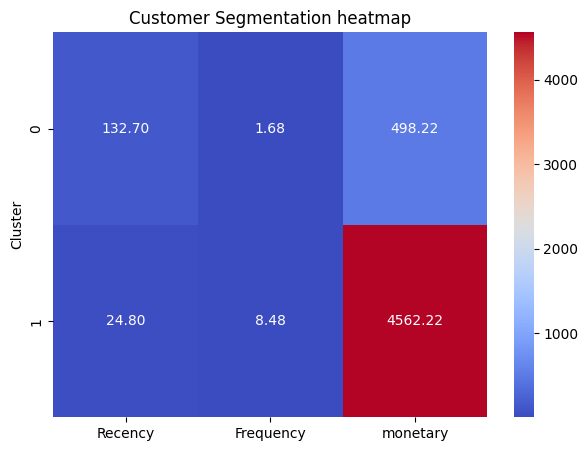

In [119]:
plt.figure(figsize = (7,5))
sns.heatmap(cluster_profile,annot = True,cmap = 'coolwarm',fmt = '.2f')
plt.title('Customer Segmentation heatmap')
plt.show()

In [120]:
import pickle

pickle.dump(kmeans, open("kmeans_segmentation.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))
pickle.dump(rfm_model.columns, open("features.pkl","wb"))